In [30]:
import os 
os.chdir('../..')

import seaborn as sns
import matplotlib.pyplot as plt

from src.utils import configure_seaborn_settings
configure_seaborn_settings()

import pandas as pd


# File Exploration

In [5]:
# all image file descriptions
base11 = pd.read_excel('data/raw/annotation/Annotation_Base11.xls')
base12 = pd.read_excel('data/raw/annotation/Annotation_Base12.xls')
base13 = pd.read_excel('data/raw/annotation/Annotation_Base13.xls')
base14 = pd.read_excel('data/raw/annotation/Annotation_Base14.xls')
base21 = pd.read_excel('data/raw/annotation/Annotation_Base21.xls')
base22 = pd.read_excel('data/raw/annotation/Annotation_Base22.xls')
base23 = pd.read_excel('data/raw/annotation/Annotation_Base23.xls')
base24 = pd.read_excel('data/raw/annotation/Annotation_Base24.xls')
base31 = pd.read_excel('data/raw/annotation/Annotation_Base31.xls')
base32 = pd.read_excel('data/raw/annotation/Annotation_Base32.xls')
base33 = pd.read_excel('data/raw/annotation/Annotation_Base33.xls')
base34 = pd.read_excel('data/raw/annotation/Annotation_Base34.xls')

# combine all files to one dataframe
df = pd.concat([base11,base12,base13,base14,base21,base22,base23,base24,base31,base32,base33,base34])

In [6]:
df.head()

,Image name,Ophthalmologic department,Retinopathy grade,Risk of macular edema
0,20051019_38557_0100_PP.tif,Service Ophtalmologie Lariboisière,3,1
1,20051020_43808_0100_PP.tif,Service Ophtalmologie Lariboisière,0,0
2,20051020_43832_0100_PP.tif,Service Ophtalmologie Lariboisière,1,0
3,20051020_43882_0100_PP.tif,Service Ophtalmologie Lariboisière,2,0
4,20051020_43906_0100_PP.tif,Service Ophtalmologie Lariboisière,3,2


# Fix Grading Mistakes

In [7]:
mistakes = ['20051020_64007_0100_PP.tif', '20051020_63936_0100_PP.tif', '20060523_48477_0100_PP.tif',
           '20051020_63045_0100_PP.tif']
value_replacements = [3,1,3,0]

In [8]:
mistake_df = df[df['Image name'].isin(mistakes)]
mistake_df

,Image name,Ophthalmologic department,Retinopathy grade,Risk of macular edema
59,20051020_63045_0100_PP.tif,Service Ophtalmologie Lariboisière,3,0
65,20051020_63936_0100_PP.tif,Service Ophtalmologie Lariboisière,3,2
66,20051020_64007_0100_PP.tif,Service Ophtalmologie Lariboisière,1,2
66,20060523_48477_0100_PP.tif,Service Ophtalmologie Lariboisière,2,0


In [10]:
for indexer, mistake in enumerate(mistakes):
    df.loc[df['Image name'] == mistake, 'Retinopathy grade'] = value_replacements[indexer]


In [11]:
df[df['Image name'].isin(mistakes)]

,Image name,Ophthalmologic department,Retinopathy grade,Risk of macular edema
59,20051020_63045_0100_PP.tif,Service Ophtalmologie Lariboisière,0,0
65,20051020_63936_0100_PP.tif,Service Ophtalmologie Lariboisière,1,2
66,20051020_64007_0100_PP.tif,Service Ophtalmologie Lariboisière,3,2
66,20060523_48477_0100_PP.tif,Service Ophtalmologie Lariboisière,3,0


# Data Exploration

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Image name                 1200 non-null   object
 1   Ophthalmologic department  1200 non-null   object
 2   Retinopathy grade          1200 non-null   int64 
 3   Risk of macular edema      1200 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.9+ KB


In [14]:
df['Retinopathy grade'].describe()

count    1200.000000
mean        1.172500
std         1.216132
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: Retinopathy grade, dtype: float64

In [15]:
df['Risk of macular edema '].describe()

count    1200.000000
mean        0.314167
std         0.683756
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: Risk of macular edema , dtype: float64

In [16]:
# convert diagnoses to binary code
binary_grade = []
for grade in df['Retinopathy grade']:
    if grade == 0:
        binary_grade.append(0)
    else:
        binary_grade.append(1)
        
print(list(df['Retinopathy grade'][:10]))
print(binary_grade[:10])

df['Binary grade'] = binary_grade

[3, 0, 1, 2, 3, 0, 0, 0, 3, 0]
[1, 0, 1, 1, 1, 0, 0, 0, 1, 0]


In [17]:
# split data frames by grade
no_dr = df[df['Retinopathy grade'] == 0]
mild_dr = df[df['Retinopathy grade'] == 1]
moderate_dr = df[df['Retinopathy grade'] == 2]
severe_dr = df[df['Retinopathy grade'] == 3]

In [18]:
dataframes = [no_dr, mild_dr, moderate_dr, severe_dr, df]
names = ['no_dr', 'mild_dr', 'moderate_dr', 'severe_dr', 'final_df']

In [24]:
# export each df as it's own csv file
for name, dataframe in zip(names, dataframes):
    out_csv = f'data/processed/{name}.csv'
    dataframe.to_csv(out_csv)

FileNotFoundError: [Errno 2] No such file or directory: '/figures/number_of_cases.png'

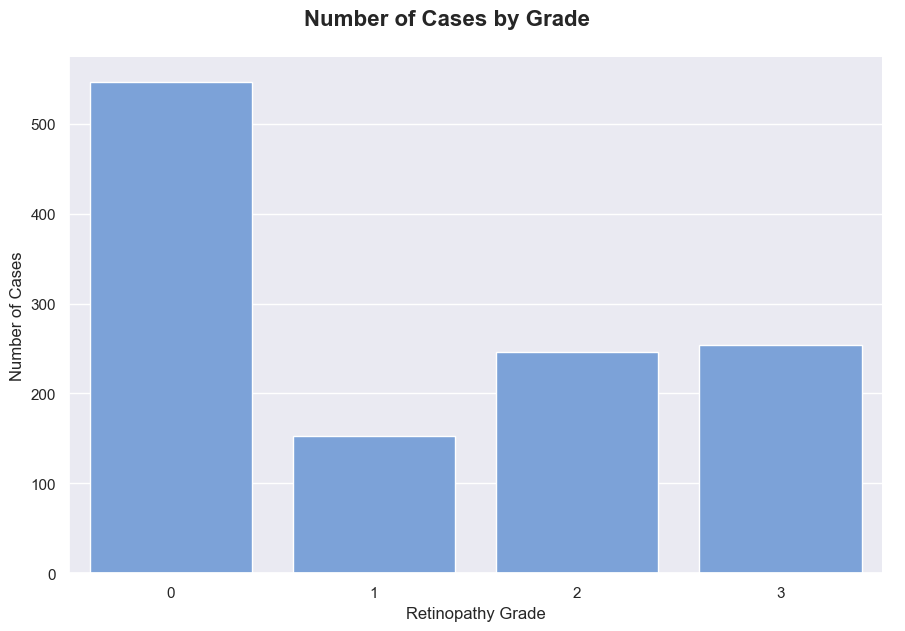

In [31]:
# Create the catplot
f = sns.catplot(x='Retinopathy grade', data=df, kind='count', height=6, aspect=1.5)

# Set the title with improved positioning and formatting
f.fig.suptitle('Number of Cases by Grade', y=1.05, x=0.5, fontsize=16, fontweight='bold')

# Set the labels for the axes
f.set_axis_labels('Retinopathy Grade', 'Number of Cases')

# Save the figure with tight layout and padding
plt.savefig('figures/number_of_cases.png', bbox_inches='tight', pad_inches=0.5)

# Display the plot
plt.show()